In [1]:
setwd("/home/orimosko/projects/phago")

In [2]:
library(DESeq2)
library(tidyverse)
library(ggplot2)
library(reshape2)
library(dplyr)
library(RColorBrewer)
library(pheatmap)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



In [3]:
library(writexl)
library(AnnotationHub)
library(ChIPseeker)
library(org.Mm.eg.db)
library(GenomicFeatures)


Loading required package: BiocFileCache

Loading required package: dbplyr


Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql



Attaching package: ‘AnnotationHub’


The following object is masked from ‘package:Biobase’:

    cache




ChIPseeker v1.42.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Qianwen Wang, Ming Li, Tianzhi Wu, Li Zhan, Lin Li, Meijun Chen, Wenqin
Xie, Zijing Xie, Erqiang Hu, Shuangbin Xu, Guangchuang Yu. Exploring
epigenomic datasets by ChIPseeker. Current Protocols. 2022, 2(10): e585

Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:dplyr’:

    select






# Loading and annotating the peaks

In [4]:
cts <- read.delim("/mc_disk2/data/atac_data/peak_counts_mouse.txt", comment.char="#")
rownames(cts) <- cts$Geneid

In [5]:
colnames(cts)[7:ncol(cts)] = substring(colnames(cts)[7:ncol(cts)], 33) %>%
    str_split("_S") %>%
    unlist() %>%
    .[seq(1, length(.), 2)]

In [6]:
colnames(cts)[15] = 'Rep_3_rodo_hi'

In [7]:
countmat <- as.matrix(cts[ ,-(1:6)])  # drop annotation columns

In [8]:
samples <- data.frame(
  sample = colnames(countmat),
  condition = factor(rep(c("hi","int","low","neg"), 3), levels = c("neg","low","int","hi")),
  replicate = rep(1:3, each=4)
)


In [9]:
rownames(samples) <- samples$sample

In [10]:
long_df = countmat %>%
    melt(varnames = c("peak_name", "sample"), value.name = "count") %>%
    mutate(Rep=substring(sample, 5, 5), rodo=factor(str_split_i(sample, "_", 4), levels=c("neg","low","int","hi")))

In [11]:
ah <- AnnotationHub()

In [12]:
hits = query(ah, c("Mus musculus","mm39","TxDb"))


In [13]:
hits

AnnotationHub with 6 records
# snapshotDate(): 2024-10-28
# $dataprovider: UCSC
# $species: Mus musculus
# $rdataclass: TxDb
# additional mcols(): taxonomyid, genome, description,
#   coordinate_1_based, maintainer, rdatadateadded, preparerclass, tags,
#   rdatapath, sourceurl, sourcetype 
# retrieve records with, e.g., 'object[["AH84139"]]' 

             title                                    
  AH84139  | TxDb.Mmusculus.UCSC.mm39.refGene.sqlite  
  AH111586 | TxDb.Mmusculus.UCSC.mm39.knownGene.sqlite
  AH114095 | TxDb.Mmusculus.UCSC.mm39.knownGene.sqlite
  AH114096 | TxDb.Mmusculus.UCSC.mm39.refGene.sqlite  
  AH116720 | TxDb.Mmusculus.UCSC.mm39.refGene.sqlite  
  AH117077 | TxDb.Mmusculus.UCSC.mm39.knownGene.sqlite

In [14]:
mcols(hits)[, c("title","rdatadateadded","rdatapath","sourceurl","maintainer")]

DataFrame with 6 rows and 5 columns
                          title rdatadateadded              rdatapath
                    <character>    <character>            <character>
AH84139  TxDb.Mmusculus.UCSC...     2020-10-20 ucsc/standard/3.12/T..
AH111586 TxDb.Mmusculus.UCSC...     2023-04-06 ucsc/standard/3.17/T..
AH114095 TxDb.Mmusculus.UCSC...     2023-10-05 ucsc/standard/3.18/T..
AH114096 TxDb.Mmusculus.UCSC...     2023-10-05 ucsc/standard/3.18/T..
AH116720 TxDb.Mmusculus.UCSC...     2024-04-02 ucsc/standard/3.19/T..
AH117077 TxDb.Mmusculus.UCSC...     2024-09-30 ucsc/standard/3.20/T..
                      sourceurl             maintainer
                    <character>            <character>
AH84139  http://genome.ucsc.e.. Bioconductor Maintai..
AH111586 http://genome.ucsc.e.. Bioconductor Maintai..
AH114095 http://genome.ucsc.e.. Bioconductor Maintai..
AH114096 http://genome.ucsc.e.. Bioconductor Maintai..
AH116720 http://genome.ucsc.e.. Bioconductor Maintai..
AH117077 http://gen

In [15]:
txdb = ah[['AH116720']]

loading from cache



In [16]:
gr_all = makeGRangesFromDataFrame(cts)
gr_all$peak_name = rownames(cts)

In [17]:
seqlevelsStyle(gr_all) <- seqlevelsStyle(txdb)[1]
peakAnno <- annotatePeak(gr_all, TxDb = txdb, tssRegion = c(-3000, 3000),
                         annoDb = "org.Mm.eg.db")   # gets gene symbols


>> preparing features information...		 2026-04-05 03:10:06 PM 
>> identifying nearest features...		 2026-04-05 03:10:06 PM 
>> calculating distance from peak to TSS...	 2026-04-05 03:10:07 PM 
>> assigning genomic annotation...		 2026-04-05 03:10:07 PM 
>> adding gene annotation...			 2026-04-05 03:10:15 PM 


'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2026-04-05 03:10:15 PM 
>> done...					 2026-04-05 03:10:15 PM 


In [18]:
peak_annot_df = as.data.frame(peakAnno) %>%
    mutate(simple_annot = ifelse(grepl("Intron", annotation), "Intron",
                          ifelse(grepl("Exon", annotation), "Exon",
                          ifelse(grepl("Promoter", annotation), "Promoter",annotation))))
peak_annots = paste(peak_annot_df$SYMBOL, peak_annot_df$simple_annot, sep="; ")
names(peak_annots) = peak_annot_df$peak_name

In [19]:
peak_annot_df = peak_annot_df %>% column_to_rownames('peak_name')

In [20]:
# make annotation lookup (from peak_annot_df which you already created)
peak_annot_lookup <- peak_annot_df %>%
    as.data.frame() %>%
    rownames_to_column("peak_name") %>%
    dplyr::select(peak_name, SYMBOL, simple_annot)

In [21]:
HM_ORDER = c('Rep_1_rodo_neg', 'Rep_2_rodo_neg', 'Rep_3_rodo_neg', 
             'Rep_1_rodo_low', 'Rep_2_rodo_low', 'Rep_3_rodo_low',
             'Rep_1_rodo_int', 'Rep_2_rodo_int', 'Rep_3_rodo_int',
             'Rep_1_rodo_hi', 'Rep_2_rodo_hi', 'Rep_3_rodo_hi')

In [22]:
new_up_and_corr_genes = c('Fth1',
 'Wfdc17',
 'Ccl9',
 'Fabp5',
 'Cstb',
 'Marco',
 'Ctsk',
 'Cd63',
 'Lgals3',
 'Lyz2',
 'Esd',
 'Ftl1',
 'Cd68',
 'Rnh1',
 'Ear6',
 'Gpnmb',
 'Mt1',
 'Capg',
 'Tuba1c',
 'Crip1',
 'Acp5',
 'Lgals1',
 'Sod2',
 'Calm1',
 'Calr',
 'Tmsb10',
 'Gapdh',
 'Nme1',
 'Slc39a2',
 'Mrpl52',
 'Emp3',
 'Clec4d',
 'Anxa4',
 'Ctsb',
 'Tyms',
 'Ctsz',
 'Anpep',
 'Tceal9',
 'Msr1',
 'Manf',
 'Ccl17',
 'Cyba',
 'Atp5k',
 'Glrx',
 'Cd24a',
 'Atp6v1c1',
 'Tspo',
 'Calm3',
 'Prdx1',
 'Atp5mpl',
 'Ctsc',
 'Anxa5',
 'Mt2',
 'Bcap31',
 'Hint1',
 'Vat1',
 'Eno1b',
 'Pycard',
 'Aldoa',
 'Cav1',
 'Gla',
 'Fabp4',
 'Nqo2',
 'Atp6v0b',
 'Mfge8',
 'Timm13')

In [23]:
NONPHAGO_COLOR = "#00A86B"
RODO_LOW_COLOR = "#FF97E2"
RODO_INT_COLOR = "#ff22c0"
RODO_HIGH_COLOR = "#7f4a99"

# Initial PCA and HM

In [24]:
dds <- DESeqDataSetFromMatrix(countData = countmat, colData = samples, design = ~ condition)
dds <- dds[rowSums(counts(dds)) >= 10, ]   # keep peaks with >=10 reads
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [25]:
vsd = vst(dds, blind=TRUE)

using ntop=500 top features by variance

Saving 6.67 x 6.67 in image


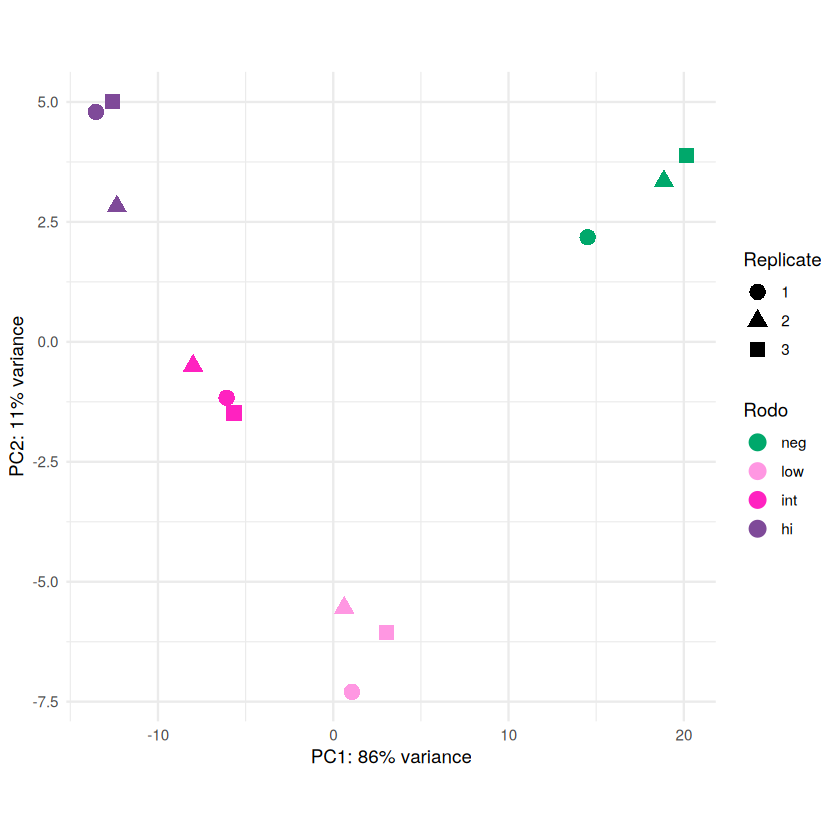

In [26]:
pca_data <- plotPCA(vsd, intgroup = c("condition", "replicate"), returnData = TRUE)
percentVar <- round(100 * attr(pca_data, "percentVar"))

ggplot(pca_data, aes(x = PC1, y = PC2, color = condition, shape = as.character(replicate))) +
    geom_point(size = 4) +
    xlab(paste0("PC1: ", percentVar[1], "% variance")) +
    ylab(paste0("PC2: ", percentVar[2], "% variance")) +
    scale_color_manual(values = c(NONPHAGO_COLOR, RODO_LOW_COLOR, RODO_INT_COLOR, RODO_HIGH_COLOR), name = "Rodo") +
    scale_shape_discrete(name = "Replicate") +
    theme_minimal() +
    theme(aspect.ratio = 1)
    
ggsave("PCA.pdf")


# Heatmap

In [27]:
peak_list = c("Peak_5091",
"Peak_8614",
"Peak_4554",
"Peak_8625",
"Peak_8617",
"Peak_23814",
"Peak_38381",
"Peak_23106",
"Peak_30219",
"Peak_6409",
"Peak_4742",
"Peak_56983",
"Peak_47968",
"Peak_26072",
"Peak_47987",
"Peak_29447",
"Peak_41954",
"Peak_37310",
"Peak_6410",
"Peak_13130",
"Peak_18171",
"Peak_50327",
"Peak_26073",
"Peak_27687",
"Peak_32823",
"Peak_37309",
"Peak_9955",
"Peak_60640",
"Peak_2202")

In [28]:
mat <- assay(vsd)[peak_list, ]
mat_scaled <- t(scale(t(mat)))  # scale each peak

In [29]:
rownames(mat_scaled) = peak_annot_df[rownames(mat_scaled),'SYMBOL']

In [30]:
col_ann <- data.frame(
  rodo = factor(rep(c("neg","low","int","hi"), each = 3),
                levels = c("neg","low","int","hi"))
)
rownames(col_ann) <- HM_ORDER

ann_colors <- list(
  rodo = c(
    neg = NONPHAGO_COLOR,
    low = RODO_LOW_COLOR,
    int = RODO_INT_COLOR,
    hi  = RODO_HIGH_COLOR
  )
)


In [31]:
bwr_cols <- colorRampPalette(c("blue","white","red"))(100)


In [32]:
bwr_n <- 101
bwr_cols <- colorRampPalette(c("blue","white","red"))(bwr_n)
max_abs <- max(abs(mat_scaled[, HM_ORDER]), na.rm = TRUE)
breaks <- seq(-max_abs, max_abs, length.out = bwr_n + 1)

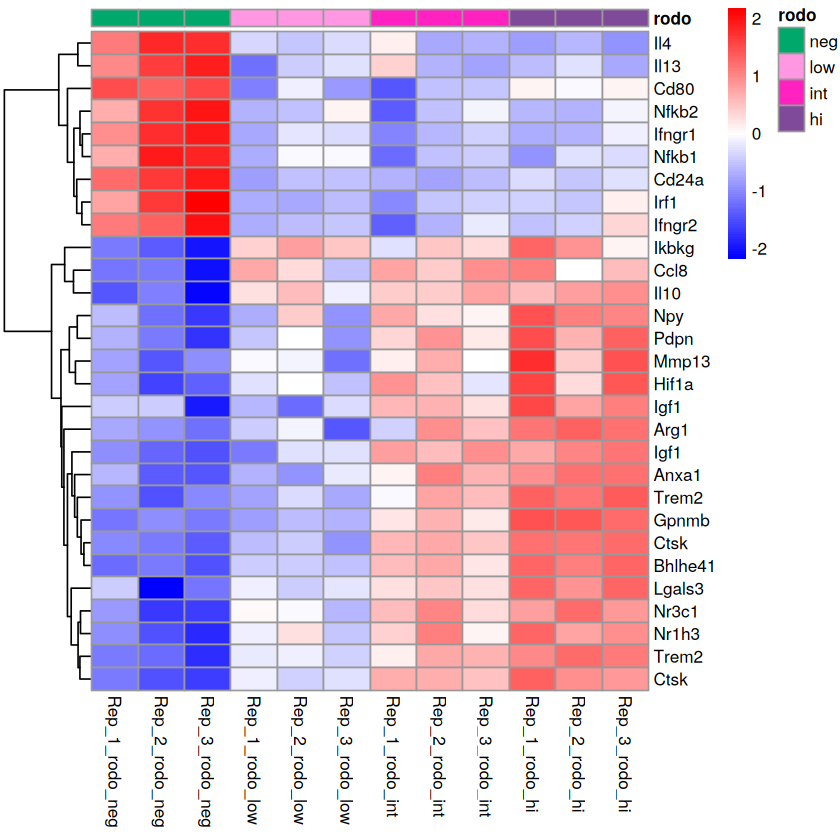

In [33]:
hm = pheatmap(
    mat_scaled[, HM_ORDER],
    color = bwr_cols,
    breaks = breaks,           # enforces center = 0 and symmetric scale
    cluster_rows = TRUE, # IF YOU WANT TO ORDER MANUALLY CHANGE TO FALSE (ALL CAPITAL)
    cluster_cols = FALSE,
    fontsize_row = 10,
    annotation_col = col_ann,
    annotation_colors = ann_colors,
    annotation_legend = TRUE
)

In [75]:
pdf("top_peaks_heatmap.pdf")
hm
dev.off()

agg_record_122411546 
                   2